In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #绘图工具
import seaborn as sns
import warnings
import random
import time
import torch
from sklearn.utils import shuffle
warnings.filterwarnings("ignore")
#设置jupyter显示多行结果
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all' #默认为'last'
# #显示所有列
pd.set_option('display.max_columns', None) #原来中间会有部分列的显示被省略
# #显示所有行
# pd.set_option('display.max_rows', None)
#设置value的显示长度为100，默认为50
pd.set_option('max_colwidth',100)
plt.rcParams['font.sans-serif'] = ['SimHei']  #显示中文
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号

In [2]:
## refer to https://github.com/bioannidis/my_dgl/blob/0aca566000fb9b01c6191909260f5a1f4d262449/examples/pytorch/gcmc/data.py

In [3]:
#  ['id', 'gender', 'age', 'occupation', 'zip_code']
user = pd.read_csv('./ml-100k/u.user', sep='|', header=None, names=['id', 'age', 'gender', 'occupation', 'zip_code'])
user["id"] = user["id"].apply(lambda x:x-1)
user

,id,age,gender,occupation,zip_code
0,0,24,M,technician,85711
1,1,53,F,other,94043
2,2,23,M,writer,32067
3,3,24,M,technician,43537
4,4,33,F,other,15213
...,...,...,...,...,...
938,938,26,F,student,33319
939,939,32,M,administrator,02215
940,940,20,M,student,97229
941,941,48,F,librarian,78209


In [4]:
user["age"].nunique()
user["age"].max()
user["age"].min()

61

73

7

In [5]:
pd.get_dummies(user,columns=["occupation"])
pd.get_dummies(user["occupation"])

,id,age,gender,zip_code,occupation_administrator,occupation_artist,occupation_doctor,occupation_educator,occupation_engineer,occupation_entertainment,occupation_executive,occupation_healthcare,occupation_homemaker,occupation_lawyer,occupation_librarian,occupation_marketing,occupation_none,occupation_other,occupation_programmer,occupation_retired,occupation_salesman,occupation_scientist,occupation_student,occupation_technician,occupation_writer
0,0,24,M,85711,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,53,F,94043,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2,2,23,M,32067,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,3,24,M,43537,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,4,33,F,15213,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,938,26,F,33319,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
939,939,32,M,02215,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
940,940,20,M,97229,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
941,941,48,F,78209,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


,administrator,artist,doctor,educator,engineer,entertainment,executive,healthcare,homemaker,lawyer,librarian,marketing,none,other,programmer,retired,salesman,scientist,student,technician,writer
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
939,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
940,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
941,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [6]:
# We take the age, gender, and the one-hot encoding of the occupation as the user features.
ages = user['age'].values.astype(np.float32)
gender = (user['gender'] == 'F').values.astype(np.float32)
# all_occupations = set(user['occupation'])
# occupation_map = {ele: i for i, ele in enumerate(all_occupations)}
# occupation_one_hot = np.zeros(shape=(user.shape[0], len(all_occupations)),
#                               dtype=np.float32)
# occupation_one_hot[np.arange(user.shape[0]),
#                    np.array([occupation_map[ele] for ele in user['occupation']])] = 1
occupation_one_hot = pd.get_dummies(user["occupation"]).values
user_features = np.concatenate([ages.reshape((user.shape[0], 1)) / 50.0,
                                gender.reshape((user.shape[0], 1)),
                                occupation_one_hot], axis=1)
user_features
user_features.shape

array([[0.48, 0.  , 0.  , ..., 0.  , 1.  , 0.  ],
       [1.06, 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.46, 0.  , 0.  , ..., 0.  , 0.  , 1.  ],
       ...,
       [0.4 , 0.  , 0.  , ..., 1.  , 0.  , 0.  ],
       [0.96, 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.44, 0.  , 0.  , ..., 1.  , 0.  , 0.  ]], dtype=float32)

(943, 23)

In [7]:
GENRES_ML_100K =\
    ['unknown', 'Action', 'Adventure', 'Animation',
     'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
     'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
     'Thriller', 'War', 'Western']
GENRES = GENRES_ML_100K

In [9]:
#   movie id | movie title | release date | video release date | IMDb URL | [genres]
item = pd.read_csv("./ml-100k/u.item", sep='|', header=None, names=['id', 'title', 'release_date', 'video_release_date', 'url'] + GENRES, encoding="ISO-8859-1")
item["id"] = item["id"].apply(lambda x:x-1)
item

,id,title,release_date,video_release_date,url,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%20(1995),0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(1995),0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,2,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%20(1995),0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,3,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%20(1995),0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,4,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1677,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+(1997),0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1678,1678,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(1998),0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0
1679,1679,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
1680,1680,You So Crazy (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?You%20So%20Crazy%20(1994),0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [12]:
import torchtext
import re
from torchtext.legacy.data import Field,TabularDataset,Iterator,BucketIterator

TEXT = Field(tokenize=str.split, tokenizer_language='en_core_web_sm')
embedding = torchtext.vocab.GloVe(name='840B', dim=300)

title_embedding = np.zeros(shape=(item.shape[0], 300), dtype=np.float32)
release_years = np.zeros(shape=(item.shape[0], 1), dtype=np.float32)
p = re.compile(r'(.+)\s*\((\d+)\)')
for i, title in enumerate(item['title']):
    match_res = p.match(title)
    if match_res is None:
        print('{} cannot be matched, index={}'.format(title, i))
        title_context, year = title, 1950
    else:
        title_context, year = match_res.groups()
    # We use average of glove
    title_embedding[i, :] = embedding.get_vecs_by_tokens(TEXT.tokenize(title_context)).numpy().mean(axis=0)
    release_years[i] = float(year)
movie_features = np.concatenate((title_embedding,
                                 (release_years - 1950.0) / 100.0,
                                 item[GENRES]),
                                axis=1)
movie_features
movie_features.shape

.vector_cache/glove.840B.300d.zip: 2.18GB [11:48, 3.07MB/s]                                                        
100%|████████████████████████████████████████████████████████████████▉| 2196016/2196017 [03:01<00:00, 12122.03it/s]


unknown cannot be matched, index=266


array([[-0.20743001,  0.0356505 , -0.31899694, ...,  0.        ,
         0.        ,  0.        ],
       [-0.27465001, -0.23215   ,  0.077449  , ...,  1.        ,
         0.        ,  0.        ],
       [ 0.28824049,  0.0409821 , -0.00722   , ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 0.11382455,  0.46856499,  0.2314675 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.3156133 ,  0.09081334, -0.06775966, ...,  0.        ,
         0.        ,  0.        ],
       [-0.132769  ,  0.19844516, -0.03564933, ...,  0.        ,
         0.        ,  0.        ]])

(1682, 320)

In [13]:
data_df = pd.read_csv("./ml-100k.csv",sep="\t").rename(columns={"user":"uid","item":"iid"})[["label","uid","iid"]]
data_df

,label,uid,iid
0,1,258,254
1,1,258,285
2,1,258,297
3,1,258,184
4,1,258,172
...,...,...,...
99995,1,728,688
99996,0,728,312
99997,0,728,327
99998,1,728,747


In [14]:
user_df = pd.DataFrame(user_features)
movie_df = pd.DataFrame(movie_features)
user_df.columns = ["u"+str(i) for i in range(23)]
movie_df.columns = ["i"+str(i) for i in range(320)]
user_df = user_df.reset_index().rename(columns={"index":"uid"})
movie_df = movie_df.reset_index().rename(columns={"index":"iid"})
user_df
movie_df

,uid,u0,u1,u2,u3,u4,u5,u6,u7,u8,u9,u10,u11,u12,u13,u14,u15,u16,u17,u18,u19,u20,u21,u22
0,0,0.48,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,1.06,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0.46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,0.48,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,0.66,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,938,0.52,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
939,939,0.64,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
940,940,0.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
941,941,0.96,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,iid,i0,i1,i2,i3,i4,i5,i6,i7,i8,i9,i10,i11,i12,i13,i14,i15,i16,i17,i18,i19,i20,i21,i22,i23,i24,i25,i26,i27,i28,i29,i30,i31,i32,i33,i34,i35,i36,i37,i38,i39,i40,i41,i42,i43,i44,i45,i46,i47,i48,i49,i50,i51,i52,i53,i54,i55,i56,i57,i58,i59,i60,i61,i62,i63,i64,i65,i66,i67,i68,i69,i70,i71,i72,i73,i74,i75,i76,i77,i78,i79,i80,i81,i82,i83,i84,i85,i86,i87,i88,i89,i90,i91,i92,i93,i94,i95,i96,i97,i98,i99,i100,i101,i102,i103,i104,i105,i106,i107,i108,i109,i110,i111,i112,i113,i114,i115,i116,i117,i118,i119,i120,i121,i122,i123,i124,i125,i126,i127,i128,i129,i130,i131,i132,i133,i134,i135,i136,i137,i138,i139,i140,i141,i142,i143,i144,i145,i146,i147,i148,i149,i150,i151,i152,i153,i154,i155,i156,i157,i158,i159,i160,i161,i162,i163,i164,i165,i166,i167,i168,i169,i170,i171,i172,i173,i174,i175,i176,i177,i178,i179,i180,i181,i182,i183,i184,i185,i186,i187,i188,i189,i190,i191,i192,i193,i194,i195,i196,i197,i198,i199,i200,i201,i202,i203,i204,i205,i206,i207,i208,i209,i210,i211,i212,i213,i214,i215,i216,i217,i218,i219,i220,i221,i222,i223,i224,i225,i226,i227,i228,i229,i230,i231,i232,i233,i234,i235,i236,i237,i238,i239,i240,i241,i242,i243,i244,i245,i246,i247,i248,i249,i250,i251,i252,i253,i254,i255,i256,i257,i258,i259,i260,i261,i262,i263,i264,i265,i266,i267,i268,i269,i270,i271,i272,i273,i274,i275,i276,i277,i278,i279,i280,i281,i282,i283,i284,i285,i286,i287,i288,i289,i290,i291,i292,i293,i294,i295,i296,i297,i298,i299,i300,i301,i302,i303,i304,i305,i306,i307,i308,i309,i310,i311,i312,i313,i314,i315,i316,i317,i318,i319
0,0,-0.207430,0.035650,-0.318997,-0.069318,-0.390787,-0.131280,-0.139950,-0.184816,0.332380,0.495135,-0.078001,-0.169405,-0.056135,0.503885,0.054155,-0.013300,0.282735,0.047238,-0.075137,0.002618,0.005060,0.069535,0.272747,0.138668,0.365330,0.513440,0.191065,0.001249,-0.130860,-0.150298,-0.250769,0.013580,-0.400790,0.489465,0.621570,-0.021565,0.205085,0.337815,0.164320,-0.084042,0.333720,-0.127494,-0.196915,-0.053705,0.037438,0.023380,-0.167445,0.093710,0.027224,-0.048375,-0.170384,-0.096261,-0.039249,0.263912,-0.022180,0.335465,-0.087249,-0.196250,-0.032569,-0.014957,0.269830,0.235120,0.003513,0.042450,0.014070,-0.034210,0.202024,-0.076969,-0.266430,0.235770,0.079330,-0.155693,-0.069795,-0.047753,0.651065,0.130085,0.151314,0.127755,0.404850,0.211645,0.189020,-0.115040,-0.192002,0.322640,-0.265140,-0.100966,-1.045260,0.372805,-0.005740,0.009045,-0.019895,0.205246,-0.319905,-0.268059,-0.220560,0.002018,-0.104830,-0.209066,0.386200,-0.126815,-0.043515,-0.022924,-0.132415,0.081313,0.081900,2.600950,-0.153095,-0.005795,-0.365720,0.132905,0.332051,0.104838,0.242360,-0.423535,0.190560,0.191722,-0.187165,0.092052,0.131570,0.292458,-0.262332,-0.106935,0.544265,0.051575,-0.319275,0.167547,0.143971,-0.123915,-0.535360,0.160937,0.111017,0.054310,0.032704,0.000406,0.193810,0.233780,-0.011512,-0.205504,0.161446,-0.118504,-1.075625,-0.372510,0.218315,0.047840,-0.044385,-0.004501,-0.028404,0.090609,0.107876,-0.074050,-0.003041,0.343470,-0.074695,-0.033120,0.075317,-0.447965,-0.233305,0.189295,-0.310924,-0.339145,-0.222035,0.125124,0.295205,0.090255,-0.888035,0.300665,-0.024035,-0.142385,0.735180,-0.092744,0.313750,-0.153168,-0.035975,0.241190,0.112884,0.129705,0.447020,0.586950,0.186075,0.258430,0.251952,-0.012610,0.144407,-0.289362,0.027120,-0.113675,0.062887,0.066895,-0.154830,0.262515,-0.736180,-0.157703,0.021945,0.424500,-0.194605,-0.360832,0.169725,0.069840,0.173038,-0.162261,0.202076,0.037510,-0.156146,0.184050,-0.094850,0.085510,0.047107,0.276310,0.317470,0.441440,-0.117297,-0.204220,-0.105055,-0.104911,0.170730,0.294570,0.333631,0.214290,-0.284200,-0.162860,0.206775,-0.174070,0.367110,0.003055,-0.098680,0.046776,0.224885,0.277831,0.291420,0.147220,0.035159,0.413340,-0.168009,0.111005,-0.098830,0.283164,-0.067925,0.229709,0.097941,0.006900,-0.397610,-0.464450,-0.098393,-0.053898,0.000393,-0.124925,-0.196252,-0.283000,-0.062650,-0.470625,0.208100,0.268055,0.239049,-0.029000,0.304050,0.320926,0.177050,0.114485,0.171063,-0.259395,0.078037,-0.374490,-0.320005,0.204035,0.01

In [15]:
data_for_verify = data_df.merge(
    user_df,
    on=["uid"],
    how="left"
)
data_for_verify

,label,uid,iid,u0,u1,u2,u3,u4,u5,u6,u7,u8,u9,u10,u11,u12,u13,u14,u15,u16,u17,u18,u19,u20,u21,u22
0,1,258,254,0.42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,258,285,0.42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1,258,297,0.42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1,258,184,0.42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1,258,172,0.42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,728,688,0.38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
99996,0,728,312,0.38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
99997,0,728,327,0.38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
99998,1,728,747,0.38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [16]:
data_for_verify = data_for_verify.merge(
    movie_df,
    on=["iid"],
    how="left"
)
data_for_verify

,label,uid,iid,u0,u1,u2,u3,u4,u5,u6,u7,u8,u9,u10,u11,u12,u13,u14,u15,u16,u17,u18,u19,u20,u21,u22,i0,i1,i2,i3,i4,i5,i6,i7,i8,i9,i10,i11,i12,i13,i14,i15,i16,i17,i18,i19,i20,i21,i22,i23,i24,i25,i26,i27,i28,i29,i30,i31,i32,i33,i34,i35,i36,i37,i38,i39,i40,i41,i42,i43,i44,i45,i46,i47,i48,i49,i50,i51,i52,i53,i54,i55,i56,i57,i58,i59,i60,i61,i62,i63,i64,i65,i66,i67,i68,i69,i70,i71,i72,i73,i74,i75,i76,i77,i78,i79,i80,i81,i82,i83,i84,i85,i86,i87,i88,i89,i90,i91,i92,i93,i94,i95,i96,i97,i98,i99,i100,i101,i102,i103,i104,i105,i106,i107,i108,i109,i110,i111,i112,i113,i114,i115,i116,i117,i118,i119,i120,i121,i122,i123,i124,i125,i126,i127,i128,i129,i130,i131,i132,i133,i134,i135,i136,i137,i138,i139,i140,i141,i142,i143,i144,i145,i146,i147,i148,i149,i150,i151,i152,i153,i154,i155,i156,i157,i158,i159,i160,i161,i162,i163,i164,i165,i166,i167,i168,i169,i170,i171,i172,i173,i174,i175,i176,i177,i178,i179,i180,i181,i182,i183,i184,i185,i186,i187,i188,i189,i190,i191,i192,i193,i194,i195,i196,i197,i198,i199,i200,i201,i202,i203,i204,i205,i206,i207,i208,i209,i210,i211,i212,i213,i214,i215,i216,i217,i218,i219,i220,i221,i222,i223,i224,i225,i226,i227,i228,i229,i230,i231,i232,i233,i234,i235,i236,i237,i238,i239,i240,i241,i242,i243,i244,i245,i246,i247,i248,i249,i250,i251,i252,i253,i254,i255,i256,i257,i258,i259,i260,i261,i262,i263,i264,i265,i266,i267,i268,i269,i270,i271,i272,i273,i274,i275,i276,i277,i278,i279,i280,i281,i282,i283,i284,i285,i286,i287,i288,i289,i290,i291,i292,i293,i294,i295,i296,i297,i298,i299,i300,i301,i302,i303,i304,i305,i306,i307,i308,i309,i310,i311,i312,i313,i314,i315,i316,i317,i318,i319
0,1,258,254,0.42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.425297,0.152745,-0.066470,-0.109742,0.234982,-0.133772,-0.059906,-0.086011,0.132203,0.754000,-0.438290,0.136033,0.192292,0.132825,0.051140,-0.119440,-0.105901,0.515960,-0.138436,0.176773,-0.097496,-0.423645,-0.344893,-0.012083,-0.203754,0.245349,-0.085485,-0.176195,-0.278211,0.004436,0.039633,0.248869,-0.127410,0.197125,0.118603,0.002714,-0.019064,-0.072690,0.152341,-0.126409,0.134014,0.039239,-0.152163,0.029378,0.192750,0.074771,-0.121026,-0.000228,0.234158,-0.064816,0.068076,-0.069199,-0.084494,0.010292,0.049498,-0.030536,0.057116,-0.364367,0.057182,-0.146891,0.228280,-0.274783,0.030936,0.138628,0.091665,0.078918,0.116438,0.167588,-0.158770,-0.207316,0.033877,0.277546,-0.034500,0.130377,0.207013,0.138800,0.037710,-0.142940,-0.182158,-0.029848,0.036726,0.362225,0.095823,-0.200249,-0.111293,-0.017803,-0.738183,0.415865,0.363488,-0.295292,-0.154038,-0.249667,0.017027,0.217915,-0.007966,0.348273,0.157520,0.156174,0.160825,-0.088910,-0.036789,-0.050896,0.215463,0.067305,0.159411,1.908800,0.168817,-0.043500,0.062722,-0.095695,0.000983,-0.198368,0.149702,0.254715,-0.220575,-0.151275,0.157833,-0.018303,-0.089212,0.127900,-0.056606,0.005512,0.126783,-0.017710,-0.079875,0.113155,-0.102220,-0.026253,-0.256608,-0.032478,0.086358,-0.228969,-0.168853,-0.115395,0.046285,-0.107371,0.099181,0.229045,0.096669,0.041558,-0.869680,0.200605,0.087735,0.333573,-0.236463,-0.143629,-0.131187,0.013894,-0.064690,0.257539,0.220985,0.238606,0.146827,0.151705,0.062212,-0.111515,0.048876,0.145997,-0.220170,-0.166530,-0.001530,-0.175360,0.035728,0.017938,0.012628,-0.302478,0.258992,-0.208438,0.326230,0.046418,-0.121002,-0.120295,0.031871,-0.038600,-0.106798,-0.160558,0.192075,0.043185,0.185267,0.384073,0.001668,-0.239550,-0.046760,0.201205,0.043170,0.038135,-0.184337,-0.091921,-0.068487,0.091705,-0.247863,-0.096107,-0.035495,-0.067610,-0.069965,-0.053838,-0.351447,-0.059694,0.068135,0.046888,-0.009610,-0.339622,-0.107415,-0.021785,0.026985,0.140413,0.138074,0.023214,-0.045424,-0.170948,-0.076043,0.042793,0.039566,-0.147681,-0.290010,0.069933,-0.320455,-0.054038,-0.197755,-0.221169,-0.294758,-0.192733,-0.112452,0.280840,-0.115760,0.152658,0.248938,0.018893,-0.302050,0.099213,-0.016784,0.200477,0.092885,0.072623,-0.051390,-0.154143,0.041048,-0.134079,-0.076810,-0.121940,-0.076239,0.101158,0.283648

## 验证特征抽取

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
import time

### 加载查看数据
X = data_for_verify.values[:,3:]
y = data_for_verify.values[:,0]
print('data sgape:{0}, no. positive:{1}, no. negative:{2}'.format(X.shape,
                                                                  y[y==1].shape[0],
                                                                  y[y==0].shape[0]))

data sgape:(100000, 343), no. positive:55375, no. negative:44625


In [18]:
### 划分测试集训练集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

### 模型拟合
model = LogisticRegression()
model.fit(X_train, y_train)

### 查看拟合情况
train_score = model.score(X_train, y_train)
cv_score = model.score(X_test, y_test)

print('train_score:{0:.6f}, cv_score:{1:.6f}'.format(train_score, cv_score))

LogisticRegression()

train_score:0.641900, cv_score:0.642400


In [19]:
### 查看模型结果
from sklearn.metrics import roc_auc_score
y_pre = model.predict(X_test)
y_pre_proba = model.predict_proba(X_test)
y_pre_proba

print('matchs: {0}/{1}'.format(np.equal(y_pre, y_test).sum(), y_test.shape[0]))
print('auc: {0}'.format(roc_auc_score(y_test, y_pre)))
print('prob auc: {0}'.format(roc_auc_score(y_test, y_pre_proba[:,1])))

array([[0.28173448, 0.71826552],
       [0.44388648, 0.55611352],
       [0.28291197, 0.71708803],
       ...,
       [0.29708745, 0.70291255],
       [0.39790038, 0.60209962],
       [0.41861668, 0.58138332]])

matchs: 6424/10000
auc: 0.6299528323907451
prob auc: 0.6852322664327869


## PCA对item features进行降维

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei


<AxesSubplot:>

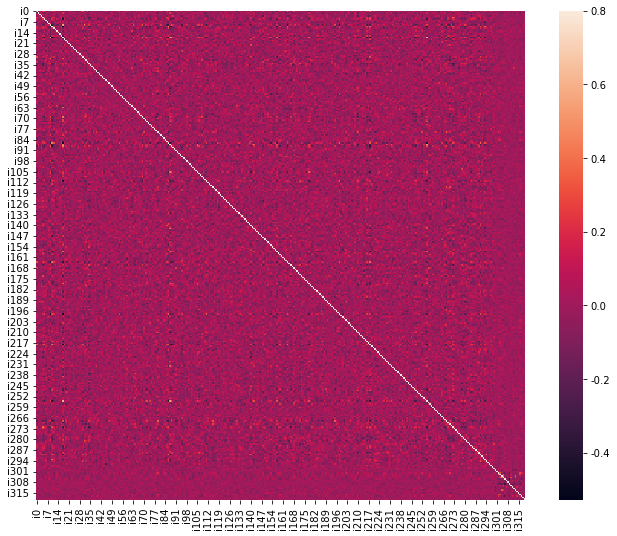

In [20]:
#可以看到自变量之间的共线性非常严重，需要重新组合变量
movie_df_for_pca = movie_df[["i"+str(i) for i in range(320)]]
corrmat = movie_df_for_pca.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)
plt.show()

In [21]:
#VIF检验是检验自变量之间多重共线性的重要方式，一般认为VIF>5就说明自变量之间存在多重共线性
from statsmodels.stats.outliers_influence import variance_inflation_factor
#考虑对数值型自变量的多重共线性检验
X=movie_df_for_pca
#务必注意，一定要加上常数项
X[len(movie_df_for_pca.columns)+1]=1
print(pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index=X.columns))

i0       3.811677
i1       3.310015
i2       2.860883
i3       3.307305
i4       4.089853
          ...    
i316     1.749447
i317     1.813489
i318     1.363271
i319     1.296514
321     39.816185
Length: 321, dtype: float64


In [22]:
from sklearn.decomposition import PCA
pca = PCA(n_components=27)
pca.fit(movie_df_for_pca)
movie_df_pca = pca.transform(movie_df_for_pca)
movie_df_for_pca.shape
movie_df_pca.shape

PCA(n_components=27)

(1682, 321)

(1682, 27)

<Figure size 864x432 with 0 Axes>

<AxesSubplot:>

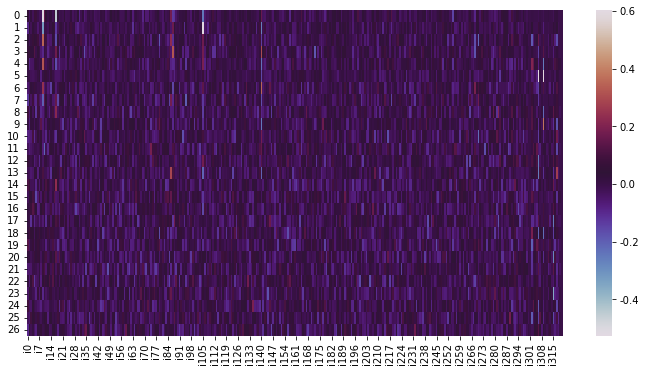

In [23]:
map= pd.DataFrame(pca.components_,columns=movie_df_for_pca.columns)
plt.figure(figsize=(12,6))
sns.heatmap(map,cmap='twilight')

In [24]:
new_movie_df = pd.concat([movie_df["iid"], pd.DataFrame(movie_df_pca)], axis=1)
new_movie_df.columns = ["iid"] + ["i"+str(i) for i in range(27)]
new_movie_df

,iid,i0,i1,i2,i3,i4,i5,i6,i7,i8,i9,i10,i11,i12,i13,i14,i15,i16,i17,i18,i19,i20,i21,i22,i23,i24,i25,i26
0,0,-0.688762,1.574607,0.133116,-0.125927,0.897221,-0.713869,-0.871113,-0.263594,-0.483008,0.606010,0.531250,1.394280,0.336511,-0.204873,-0.242937,-0.662188,-0.603296,0.149739,-0.220943,0.487265,-0.110061,0.421058,0.491370,0.207759,0.352869,-0.204194,-0.018916
1,1,3.014720,-0.028838,-1.183211,-0.231424,1.805498,-0.204245,0.406279,0.506679,1.035856,0.720915,0.193255,0.045345,0.775966,0.458159,0.299675,0.567883,0.717280,-0.134651,-0.623159,-1.131176,-0.325514,-0.287053,-0.853708,0.822714,-0.595920,-0.458626,0.574414
2,2,-1.028273,0.392793,-0.560857,1.257056,-0.472775,-0.127257,-0.215250,-0.916972,0.592528,-0.412215,0.504658,0.081036,0.623665,-0.335363,0.511057,-0.096075,-0.782410,0.247494,-0.426702,-0.649379,0.214322,-0.153956,0.155310,0.633112,0.903612,0.380277,0.155572
3,3,-0.100268,1.272389,0.308137,0.022574,-0.676872,-0.579112,0.089437,0.305334,-0.221921,1.250861,-0.310906,-0.721472,0.232644,0.156193,-0.081849,0.108620,-0.017047,-0.212266,0.100664,0.154353,0.072902,-0.212931,-0.536019,0.031946,-0.056428,-0.605589,-0.279208
4,4,2.663284,0.584895,-0.232339,-0.006023,-0.446164,0.366644,0.224911,0.048201,-0.501114,0.020707,0.770488,-0.164478,0.313535,0.675357,-0.447796,-1.319339,0.910010,-0.030351,-0.403358,-0.303163,-1.868080,-0.671557,-0.355785,0.481693,-0.396686,0.612704,-0.090778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1677,0.592308,-1.265183,0.337525,-0.031713,-0.834247,0.318597,-0.119449,0.910303,0.562002,0.670231,-0.489660,-0.042193,-0.542683,0.813489,-0.130157,0.399173,0.227618,0.562281,-0.236530,0.143799,0.101119,-0.415986,-0.405658,0.153112,-0.032806,0.132926,0.010101
1678,1678,-0.547390,0.478634,0.722330,0.079072,0.593870,-0.242277,0.075706,1.071090,-0.402893,-0.454673,0.299912,0.163779,0.188752,0.473853,-0.072703,-1.122280,-0.311072,-0.030773,-0.143190,-0.310446,-0.267976,0.137212,0.070422,-0.745873,0.189311,-0.723304,-0.730329
1679,1679,0.032248,1.031972,-0.907768,1.578784,-1.060650,0.157171,0.116521,0.437219,0.163835,-0.231815,-0.881187,-0.138665,0.957460,-0.676248,1.729775,0.164666,-0.481725,-0.067004,-0.915201,0.755354,0.334640,0.279752,0.674640,-0.086082,1.466846,0.096216,-0.153307
1680,1680,-1.240558,0.961616,0.559025,-1.609118,-0.487707,-0.640046,-0.395754,0.167499,0.303371,0.549008,-0.719271,-0.569230,0.304512,0.608730,-0.416700,0.068196,-0.058495,0.247798,-0.087689,-0.202345,0.164800,0.025298,-0.529586,-0.109518,-0.108995,-0.042135,0.116375


In [25]:
new_data_for_verify = data_df.merge(
    user_df,
    on=["uid"],
    how="left"
)
new_data_for_verify = new_data_for_verify.merge(
    new_movie_df,
    on=["iid"],
    how="left"
)
new_data_for_verify

,label,uid,iid,u0,u1,u2,u3,u4,u5,u6,u7,u8,u9,u10,u11,u12,u13,u14,u15,u16,u17,u18,u19,u20,u21,u22,i0,i1,i2,i3,i4,i5,i6,i7,i8,i9,i10,i11,i12,i13,i14,i15,i16,i17,i18,i19,i20,i21,i22,i23,i24,i25,i26
0,1,258,254,0.42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.980386,0.718306,0.694058,-0.160313,-0.479048,-0.578247,-0.680513,-0.323003,0.499115,-0.281504,0.143029,0.306002,0.408935,-0.443318,0.357123,0.268349,0.028142,-0.173823,-0.142468,-0.451480,-0.165615,0.177336,-0.629687,0.009166,-0.406254,0.340331,-0.361361
1,1,258,285,0.42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.797693,-1.059447,-0.085224,-0.212982,-0.310910,0.575682,-0.439162,0.126486,-0.048705,0.234279,0.276823,0.158842,0.021841,-0.520604,0.288629,0.114045,-0.100581,-0.278034,-0.159362,-0.181765,-0.431997,0.059700,-0.097978,-0.496924,0.208694,-0.220271,0.104189
2,1,258,297,0.42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.142907,0.520075,-1.001815,-0.001830,1.072170,-0.308852,0.889531,-0.371852,0.638174,0.426639,-0.134032,-0.009964,0.358287,0.548805,0.972492,-0.123339,0.446792,-0.648560,0.271770,-0.506946,0.185561,-0.379529,0.336709,-0.753675,-1.100031,0.074266,0.174397
3,1,258,184,0.42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.727424,1.230421,-0.307738,-0.895651,1.519956,0.396110,0.021406,0.190176,0.152046,0.222517,0.392306,-0.644251,-0.529376,0.162867,1.363720,-1.112562,-0.031906,0.281339,-0.355242,0.157374,0.174907,-0.210027,-0.371606,-1.407588,-0.339325,0.140283,-0.013100
4,1,258,172,0.42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.474893,-0.244775,-0.016515,-0.345154,0.683060,-0.424912,-1.304231,0.064300,0.376101,-0.221549,0.418816,0.386742,0.399499,-0.176696,0.019123,0.343169,0.016480,-0.288117,0.053941,0.063343,-0.692591,0.318180,-0.045487,0.110190,-0.009837,-0.741506,-0.056848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,728,688,0.38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.384074,-0.981271,-1.059256,-0.343976,0.136985,-0.189494,-0.442767,0.171805,-0.106666,-0.084044,0.680387,-0.487641,0.464604,0.210016,0.087978,-0.103061,-0.106656,-0.070877,0.410144,-0.356643,-0.061542,-0.197350,-0.064315,0.024606,-0.079106,-0.096956,-0.005188
99996,0,728,312,0.38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.717254,-0.270710,0.011881,-0.664886,1.367244,1.010535,-0.374096,-0.575083,1.002383,0.842949,-0.523008,1.017631,0.987427,-0.669808,0.825452,0.328642,0.160564,-0.512005,-0.499721,-0.293138,-0.871006,0.124995,0.874931,-1.067549,-0.021800,-0.724804,0.343556
99997,0,728,327,0.38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.150793,0.521719,-1.438844,-1.031984,0.543606,0.095682,1.460875,0.146244,0.415910,-0.934182,0.968414,0.011427,-0.001437,-0.922888,0.033141,-0.971816,0.346446,-0.193106,-0.151925,0.205946,-0.702639,0.201755,-0.206555,-0.531002,0.276845,-0.084085,0.155052
99998,1,728,747,0.38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.401107,-0.953414,-0.972598,-0.408110,0.105322,-0.178395,-0.504501,0.177526,0.030151,-0.190493,0.638178,-0.514706,0.587547,0.106867,0.248362,-0.023059,0.013035,-0.323101,0.274415,-0.399471,-0.340470,-0.056729,-0.112626,-0.331050,-0.043616,-0.255307,-0.035264


## 再次验证数据，查看PCA损失了多少

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
import time

### 加载查看数据
X = data_for_verify.values[:,3:]
y = data_for_verify.values[:,0]
print('data sgape:{0}, no. positive:{1}, no. negative:{2}'.format(X.shape,
                                                                  y[y==1].shape[0],
                                                                  y[y==0].shape[0]))
### 划分测试集训练集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

### 模型拟合
model = LogisticRegression()
model.fit(X_train, y_train)

### 查看拟合情况
train_score = model.score(X_train, y_train)
cv_score = model.score(X_test, y_test)

print('train_score:{0:.6f}, cv_score:{1:.6f}'.format(train_score, cv_score))

### 查看模型结果
from sklearn.metrics import roc_auc_score
y_pre = model.predict(X_test)
y_pre_proba = model.predict_proba(X_test)
y_pre_proba

print('matchs: {0}/{1}'.format(np.equal(y_pre, y_test).sum(), y_test.shape[0]))
print('auc: {0}'.format(roc_auc_score(y_test, y_pre)))
print('prob auc: {0}'.format(roc_auc_score(y_test, y_pre_proba[:,1])))

data sgape:(100000, 343), no. positive:55375, no. negative:44625


LogisticRegression()

train_score:0.641444, cv_score:0.649000


array([[0.31650524, 0.68349476],
       [0.54765539, 0.45234461],
       [0.36783381, 0.63216619],
       ...,
       [0.43830527, 0.56169473],
       [0.40695456, 0.59304544],
       [0.77472757, 0.22527243]])

matchs: 6490/10000
auc: 0.634698478099867
prob auc: 0.6851833216777021


In [ ]:
user_df.to_csv("user_features.csv", index=False, sep="\t")
user_df
movie_df.to_csv("item_features_before_pca.csv", index=False, sep="\t")
movie_df
new_movie_df.to_csv("item_features_pca.csv", index=False, sep="\t")
new_movie_df

,uid,u0,u1,u2,u3,u4,u5,u6,u7,u8,u9,u10,u11,u12,u13,u14,u15,u16,u17,u18,u19,u20,u21,u22
0,0,0.48,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,1.06,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0.46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,0.48,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,0.66,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,938,0.52,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
939,939,0.64,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
940,940,0.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
941,941,0.96,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
np.savetxt("user_features.txt", user_features)
user_features.shape
np.savetxt("item_features_before_pca.txt", movie_features)
movie_features.shape
np.savetxt("item_features_pca.txt", movie_df_pca)
movie_df_pca.shape

(943, 23)

(1682, 320)

(1682, 27)

In [ ]:
np.random.choice([0, 1], p=[1 - sim_attention_nb, sim_attention_nb])

In [31]:
a = np.array([0.9,0.9,0.9,0.9])
for i in range(100):
    np.random.binomial(n=1, p=a)

array([1, 1, 1, 1])

array([1, 1, 1, 1])

array([1, 1, 1, 1])

array([1, 1, 1, 1])

array([1, 0, 1, 1])

...

array([1, 1, 1, 1])

array([1, 1, 1, 1])

array([1, 1, 1, 1])

array([1, 1, 1, 0])

array([1, 0, 1, 0])

In [36]:
pred = pd.DataFrame(np.loadtxt("../pred.txt"))
pred.columns=["score"]
pred

,score
0,0.275374
1,0.634885
2,0.835288
3,0.520424
4,0.481197
...,...
9995,0.522029
9996,0.556887
9997,0.610578
9998,0.609423


In [42]:
pred[pred["score"]>=0.5].count()/pred[pred["score"]<0.5].count()

score    2.023889
dtype: float64

In [47]:
a = np.array([0.9,0.1,0.1,0.9])
b =  np.where(a>0.5, 1, 0) 
b

array([1, 0, 0, 1])

In [48]:
torch.LongTensor([1,2])

tensor([1, 2])